In [81]:
import argparse
import numpy as np
import cv2 as cv
from PIL import Image
from os import path
import yaml
import matplotlib.pyplot as plt



def parseArgs():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--dataDir", required=True)
    parser.add_argument("--calibrationPath", required=True)

    return parser.parse_args()

def toUnitVector(q):
    return q / np.linalg.norm(q)

def quaternionToRotation(q):
    w, x, y, z = toUnitVector(q)
    return np.array([
        [1 - 2*(y*y + z*z),  2*(x*y - z*w),      2*(x*z + y*w)],
        [2*(x*y + z*w),      1 - 2*(x*x + z*z),  2*(y*z - x*w)],
        [2*(x*z - y*w),      2*(y*z + x*w),      1 - 2*(x*x + y*y)]
    ])


class Projector:
    def __init__(self):
        self.image: np.ndarray
        self.pointCloud: np.ndarray
        self.cameraRotation: np.ndarray
        self.cameraPosition: np.ndarray
        self.cameraIntrinsics : np.ndarray
        self.cameraDistorsion : np.ndarray
        self.imageWidth: np.number
        self.imageHeight: np.number

    def loadImage(self, imagePath):
        img = Image.open(imagePath)
        self.image = np.asarray(img)
        self.imageHeight = self.image.shape[0]
        self.imageWidth = self.image.shape[1]

    def loadCalibration(self, calibrationPath):
        with open(calibrationPath) as file:
            calibration = yaml.load(file, yaml.SafeLoader)
            self.cameraIntrinsics = np.array(calibration["cam0"]["intrinsics"])
            self.cameraDistorsion = np.array(calibration["cam0"]["distortion_coeffs"])

    def loadPointCloud(self, pointCloudPath):
        self.pointCloud = np.load(pointCloudPath)
        self.pointCloud[:,3] = 1
        #print("pointCloud\n",self.pointCloud[:8])

    def loadOdometry(self, odometryPath):
        with open(odometryPath) as file:
            odometry = yaml.load(file,yaml.SafeLoader)
            quaternion = np.array([odometry['orientation']['w'],odometry['orientation']['x'],odometry['orientation']['y'],odometry['orientation']['z']]) 
            position = np.array([odometry['position']['x'],odometry['position']['y'],odometry['position']['z']])
            self.cameraRotation = quaternionToRotation(quaternion)
            self.cameraPosition = position


    def intrinsicsMatrix(self):
        fx,fy,u0,v0 = self.cameraIntrinsics
        result = np.array([
            [fx,0,u0],
            [0,fy,v0],
            [0,0,1]
        ])
    
        #print("intrinsicsMatrix\n",result)

        return result

    def extrinsicsMatrix(self):
        top = np.column_stack((self.cameraRotation,self.cameraPosition))
        bottom = np.array([0,0,0,1]).reshape(1,4)
        result =  np.concatenate((top,bottom))
        result = np.linalg.inv(result)
        #print("extrinsicsMatrix\n",result)
        return result


    def displayTransform(self):
        result = np.array([
        [1,0,self.imageWidth/2],
        [0,-1,self.imageHeight/2],
        [0,0,1],
        ])
        return np.linalg.inv(result)

    def projectedPointCloud(self):
        inCameraCoordinates =  self.pointCloud @ self.extrinsicsMatrix().T
        #print("inCameraCoordinates", inCameraCoordinates.shape,"\n",inCameraCoordinates[:10])
        mask = inCameraCoordinates[:,2]>0
        valid = inCameraCoordinates[mask][:,:3]
        #valid = valid / valid[:,2:]
        #print("with positive z", valid.shape,"\n",valid[:10])
        valid = valid @ self.intrinsicsMatrix().T
        #print("in image coordinates", valid.shape,"\n",valid[:10])
        valid = (valid  @ self.displayTransform().T)
        #print("in display coordinates", valid.shape,"\n",valid[:10])
        mask = (valid[:,0]>0)&(valid[:,0]<self.imageWidth)&(valid[:,1]>0)&(valid[:,1]<self.imageHeight)
        valid =valid[mask][:,:2]
        #print("inside display bounds", valid.shape,"\n",valid[:10])
        return valid



    def plot(self):
        projected_inside = self.projectedPointCloud() 
        #print("projected_inside\n",projected_inside[:10])
        plt.figure(figsize=(12, 14))
        plt.imshow(self.image)

        plt.scatter(
            projected_inside[:, 0],
            projected_inside[:, 1],
            s=3,
            c="red",
            alpha=0.7
        )

        plt.xlim(0, self.imageWidth)
        plt.ylim(self.imageHeight, 0)
        plt.xlabel("u (pixels)")
        plt.ylabel("v (pixels)")
        plt.show()

#def main():
#    args = parseArgs()
#    dataDir = path.abspath(args.dataDir)
#    calibrationPath = path.abspath(args.calibrationPath)
#    p = Projector()
#    p.loadImage(path.join(dataDir, "image.png"))
#    p.loadCalibration(calibrationPath)
#    p.loadOdometry(path.join(dataDir, "odom.yaml"))
#    p.loadPointCloud(path.join(dataDir, "pointcloud.npy"))
#
#    p.plot()
#
#
#if __name__ == "__main__":
#    main()


In [82]:
p = Projector()

In [86]:
directory = "000001"

In [87]:
p.loadImage(f"dataset/extracted/{directory}/image.png")
p.loadCalibration("dataset/hands-on-earth-calib-params-2024-06-12-12-23-16.yaml")
p.loadOdometry(f"dataset/extracted/{directory}/odom.yaml")
p.loadPointCloud(f"dataset/extracted/{directory}/pointcloud.npy")

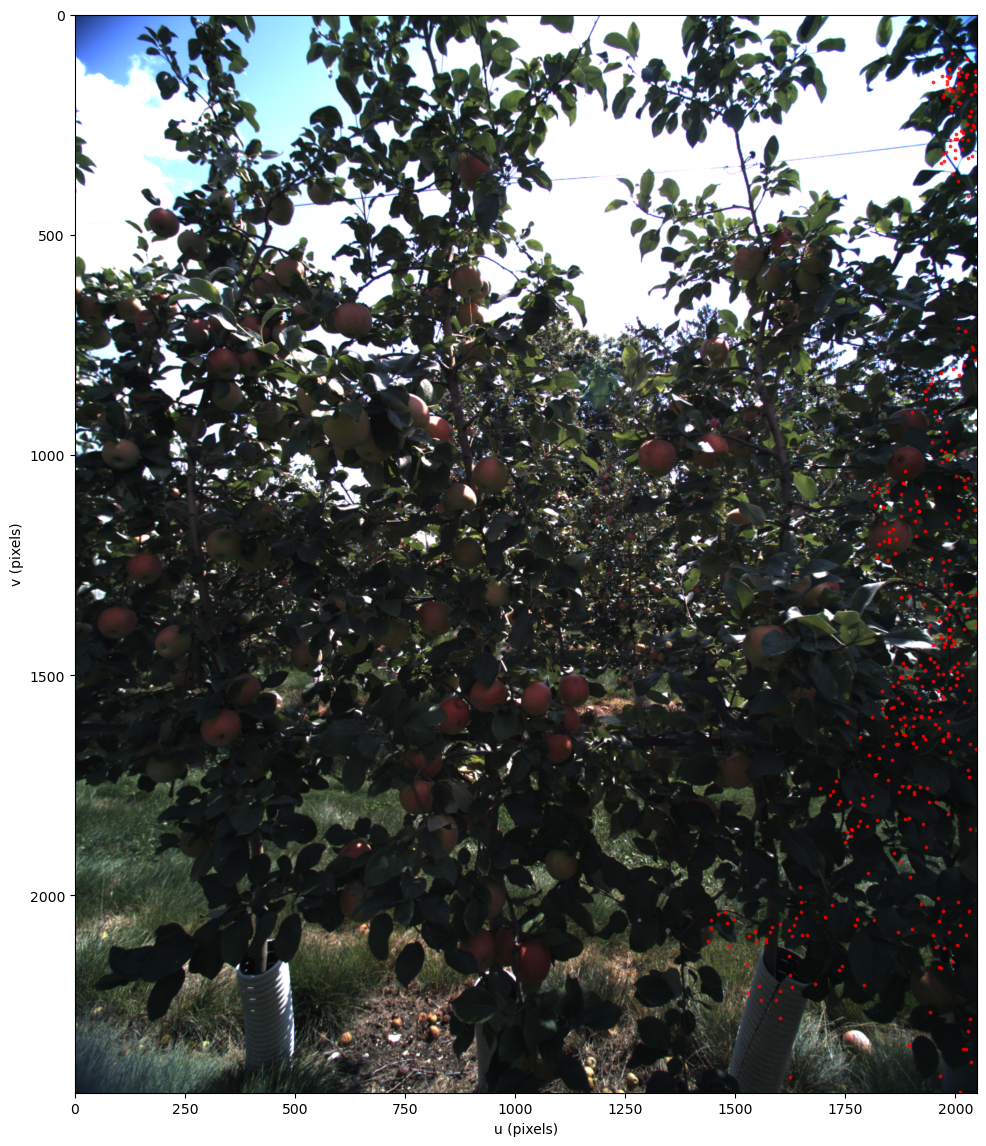

In [88]:
p.plot()